In [41]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from pathlib import Path

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
})

# ── Load history ────────────────────────────────────────────────────────
LOG_DIR    = Path(r"d:\amir lab\RS-Vamba-main\fusion\outputs\logs")
FIG_DIR    = Path(r"d:\amir lab\RS-Vamba-main\fusion\outputs\figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

with open(LOG_DIR / "history.json") as f:
    history = json.load(f)

epochs      = [h['epoch']          for h in history]
train_loss  = [h['train_loss']     for h in history]
val_loss    = [h['val_loss']       for h in history]
train_acc   = [h['train_acc']      for h in history]
val_acc     = [h['val_acc']        for h in history]
lr_vals     = [h['lr']             for h in history]
elapsed     = [h['elapsed_s']/60   for h in history]

TYPE_NAMES = [
    'Basic Counting',
    'Basic Judging',
    'Comprehensive Analysis',
    'Object Situation Analysis',
    'Reasoning-based Counting',
    'Reasoning-based Judging',
]

per_type_epochs = {
    t: [h['per_type_acc'][t] for h in history]
    for t in TYPE_NAMES
}

best_epoch = epochs[val_acc.index(max(val_acc))]
best_acc   = max(val_acc)
best_type  = history[val_acc.index(max(val_acc))]['per_type_acc']

print(f"Loaded {len(history)} epochs")
print(f"Best val acc: {best_acc:.4f} at epoch {best_epoch}")

Loaded 10 epochs
Best val acc: 0.7831 at epoch 10


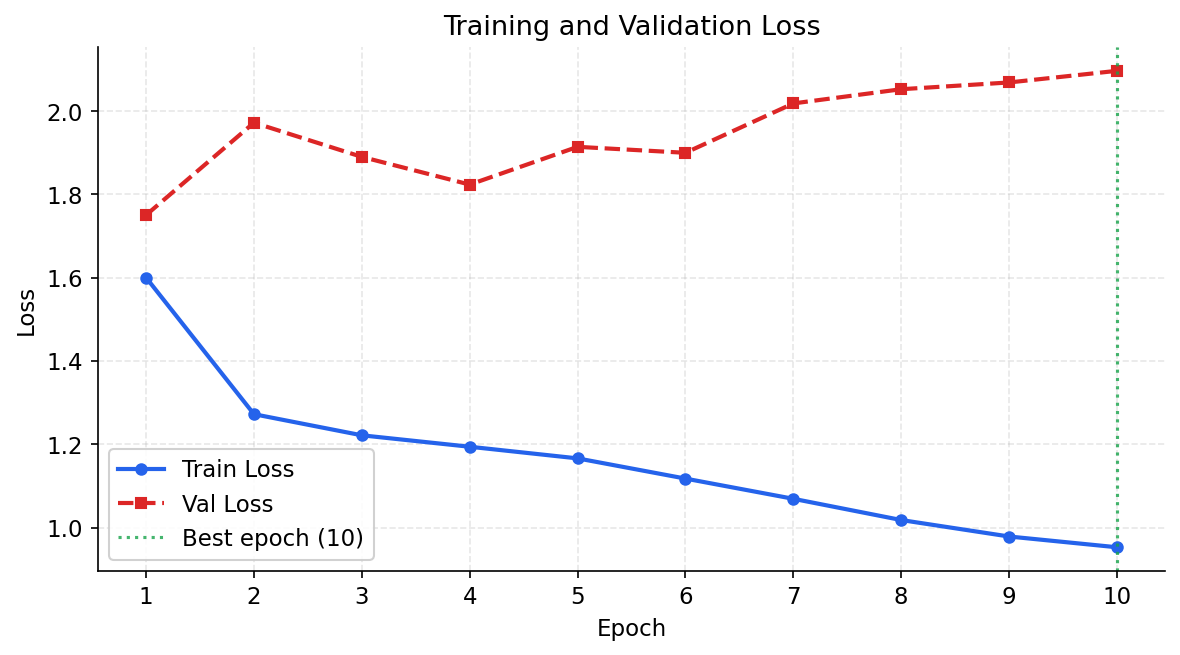

Saved fig1_loss_curves.png


In [42]:
# ── Figure 1: Loss Curves ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(epochs, train_loss, 'o-', color='#2563EB', lw=2,
        markersize=5, label='Train Loss')
ax.plot(epochs, val_loss,   's--', color='#DC2626', lw=2,
        markersize=5, label='Val Loss')

ax.axvline(best_epoch, color='#16A34A', lw=1.5,
           linestyle=':', alpha=0.8, label=f'Best epoch ({best_epoch})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.set_xticks(epochs)
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_loss_curves.png')
plt.show()
print("Saved fig1_loss_curves.png")

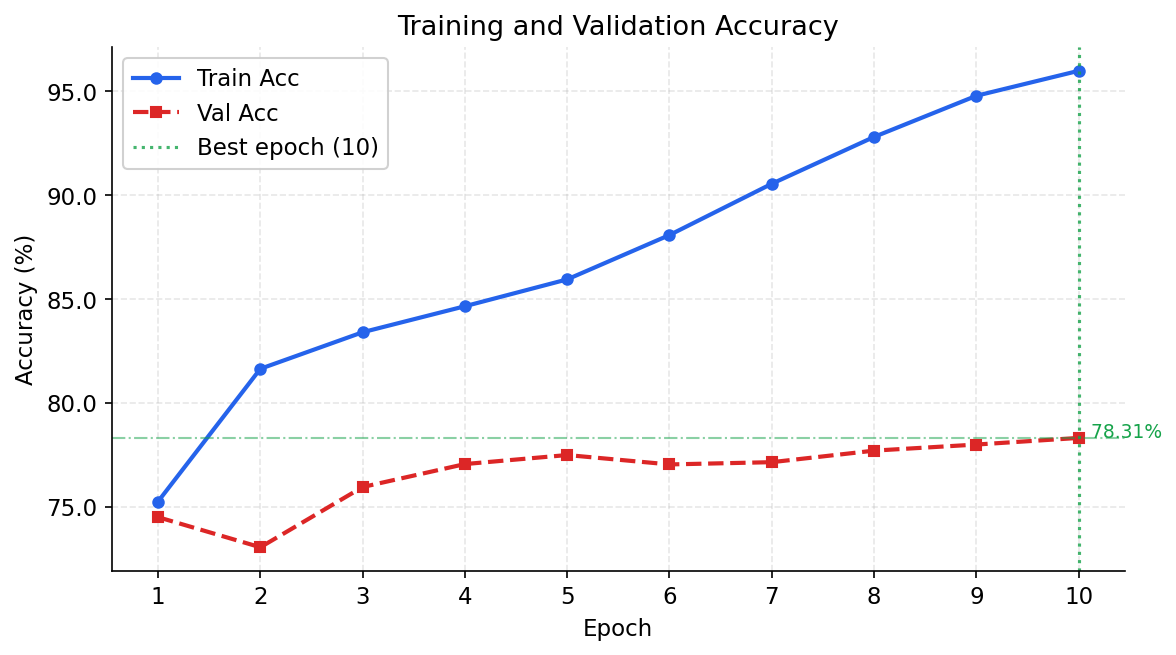

Saved fig2_accuracy_curves.png


In [43]:
# ── Figure 2: Accuracy Curves ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(epochs, [a * 100 for a in train_acc], 'o-',
        color='#2563EB', lw=2, markersize=5, label='Train Acc')
ax.plot(epochs, [a * 100 for a in val_acc],   's--',
        color='#DC2626', lw=2, markersize=5, label='Val Acc')

ax.axvline(best_epoch, color='#16A34A', lw=1.5,
           linestyle=':', alpha=0.8, label=f'Best epoch ({best_epoch})')
ax.axhline(best_acc * 100, color='#16A34A', lw=1,
           linestyle='-.', alpha=0.5)
ax.annotate(f'  {best_acc*100:.2f}%',
            xy=(epochs[-1], best_acc * 100),
            fontsize=9, color='#16A34A')

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training and Validation Accuracy')
ax.set_xticks(epochs)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_accuracy_curves.png')
plt.show()
print("Saved fig2_accuracy_curves.png")

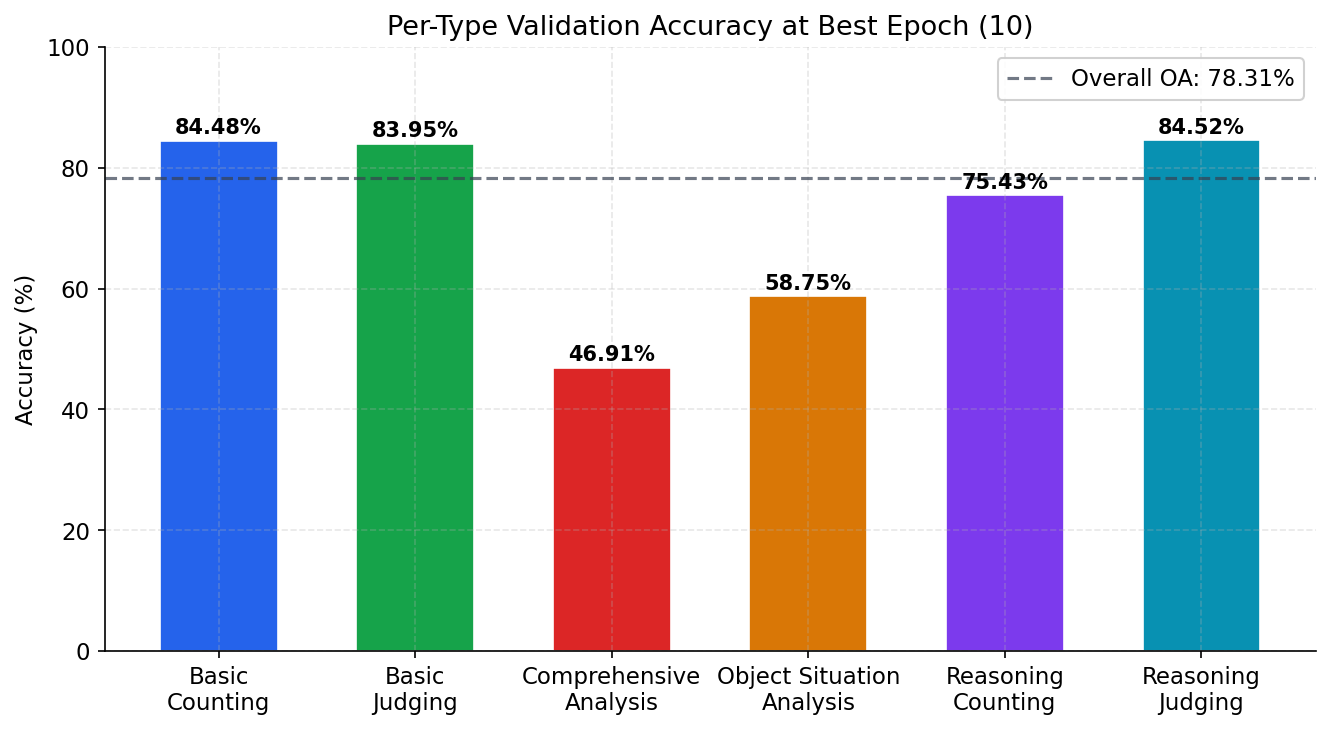

Saved fig3_per_type_accuracy.png


In [44]:
# ── Figure 3: Per-Type Accuracy at Best Epoch ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#2563EB','#16A34A','#DC2626','#D97706','#7C3AED','#0891B2']
short_names = [
    'Basic\nCounting',
    'Basic\nJudging',
    'Comprehensive\nAnalysis',
    'Object Situation\nAnalysis',
    'Reasoning\nCounting',
    'Reasoning\nJudging',
]
vals = [best_type[t] * 100 for t in TYPE_NAMES]

bars = ax.bar(short_names, vals, color=colors,
              width=0.6, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(best_acc * 100, color='#374151', lw=1.5,
           linestyle='--', alpha=0.7, label=f'Overall OA: {best_acc*100:.2f}%')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Per-Type Validation Accuracy at Best Epoch ({best_epoch})')
ax.set_ylim(0, 100)
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_per_type_accuracy.png')
plt.show()
print("Saved fig3_per_type_accuracy.png")

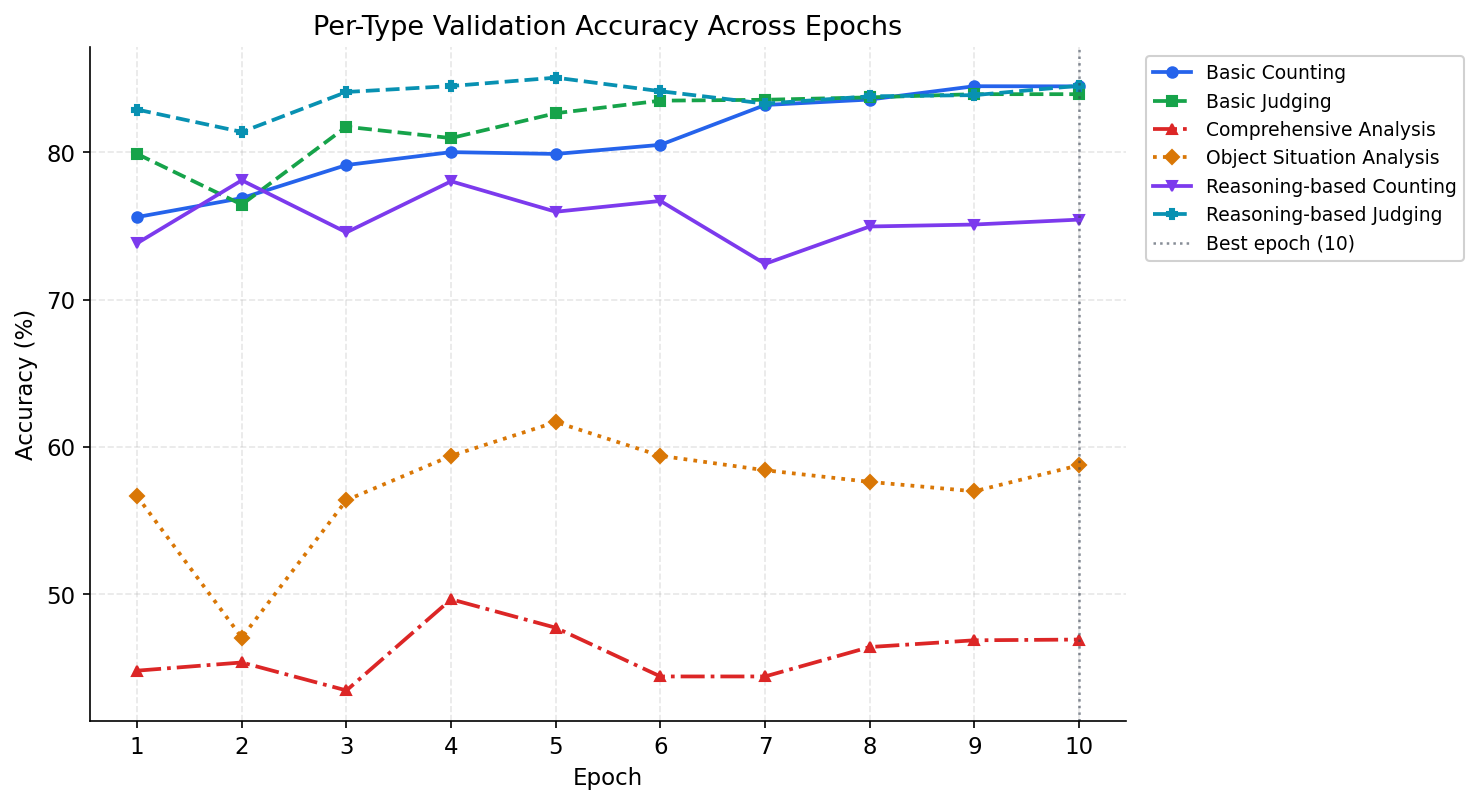

Saved fig4_per_type_across_epochs.png


In [45]:
# ── Figure 4: Per-Type Accuracy Across All Epochs (Line) ─────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))

line_styles = ['-', '--', '-.', ':', '-', '--']
markers     = ['o', 's', '^', 'D', 'v', 'P']

for i, t in enumerate(TYPE_NAMES):
    vals = [v * 100 for v in per_type_epochs[t]]
    ax.plot(epochs, vals,
            linestyle=line_styles[i],
            marker=markers[i],
            color=colors[i],
            lw=1.8, markersize=5,
            label=t)

ax.axvline(best_epoch, color='#374151', lw=1.2,
           linestyle=':', alpha=0.6, label=f'Best epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Type Validation Accuracy Across Epochs')
ax.set_xticks(epochs)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left',
          framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_per_type_across_epochs.png')
plt.show()
print("Saved fig4_per_type_across_epochs.png")

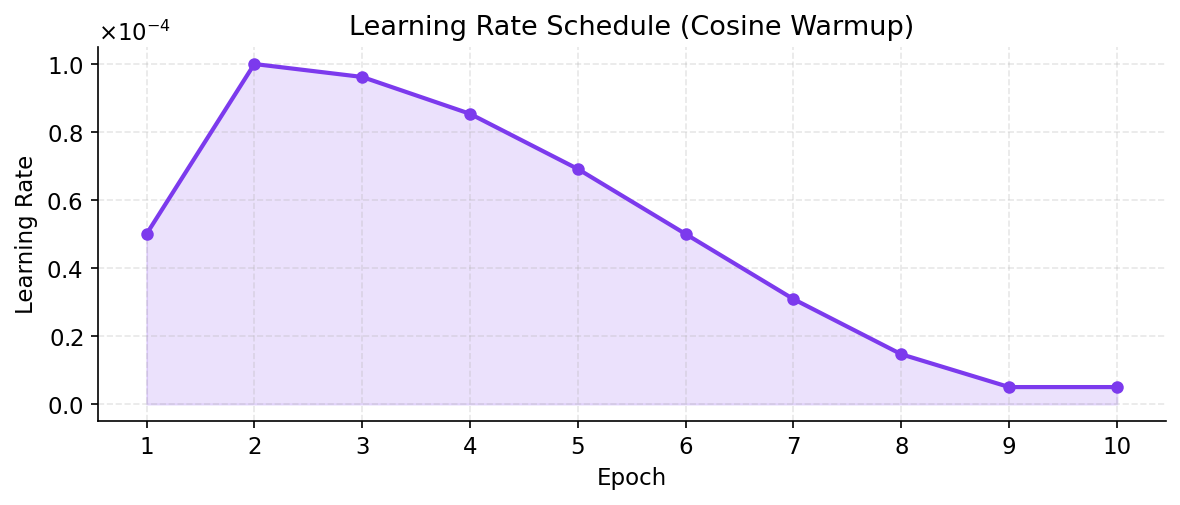

Saved fig5_lr_schedule.png


In [46]:
# ── Figure 5: LR Schedule ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(epochs, lr_vals, 'o-', color='#7C3AED', lw=2, markersize=5)
ax.fill_between(epochs, lr_vals, alpha=0.15, color='#7C3AED')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule (Cosine Warmup)')
ax.set_xticks(epochs)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_lr_schedule.png')
plt.show()
print("Saved fig5_lr_schedule.png")

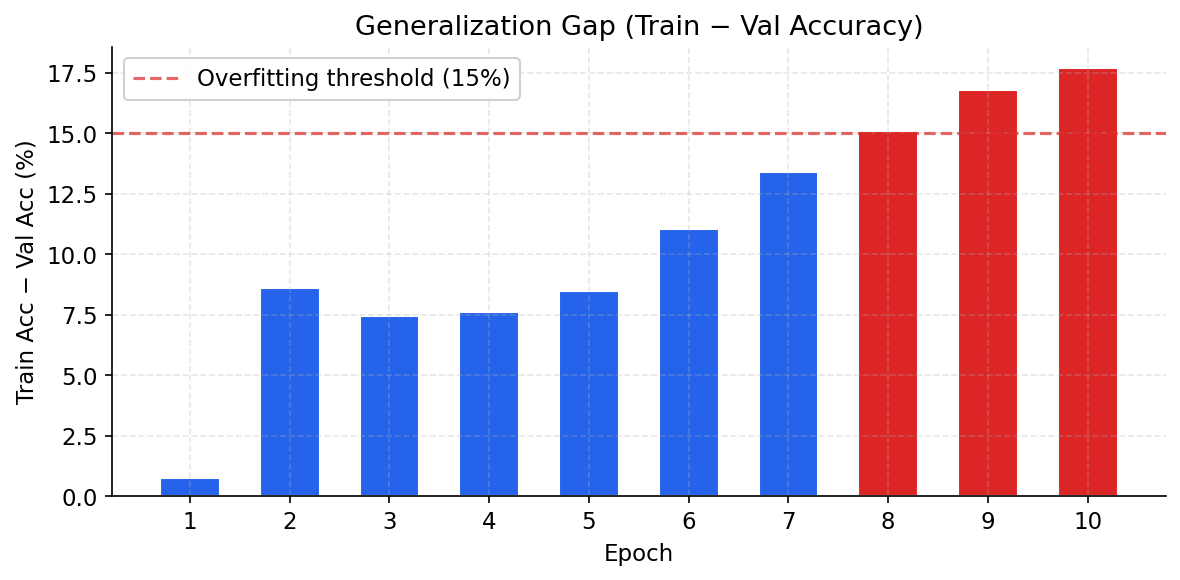

Saved fig6_generalization_gap.png


In [47]:
# ── Figure 6: Train-Val Gap (Overfitting Analysis) ───────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

gap = [t - v for t, v in zip(train_acc, val_acc)]
ax.bar(epochs, [g * 100 for g in gap],
       color=['#DC2626' if g > 0.15 else '#2563EB' for g in gap],
       width=0.6, edgecolor='white')
ax.axhline(15, color='#DC2626', lw=1.5, linestyle='--',
           alpha=0.7, label='Overfitting threshold (15%)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Acc − Val Acc (%)')
ax.set_title('Generalization Gap (Train − Val Accuracy)')
ax.set_xticks(epochs)
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_generalization_gap.png')
plt.show()
print("Saved fig6_generalization_gap.png")

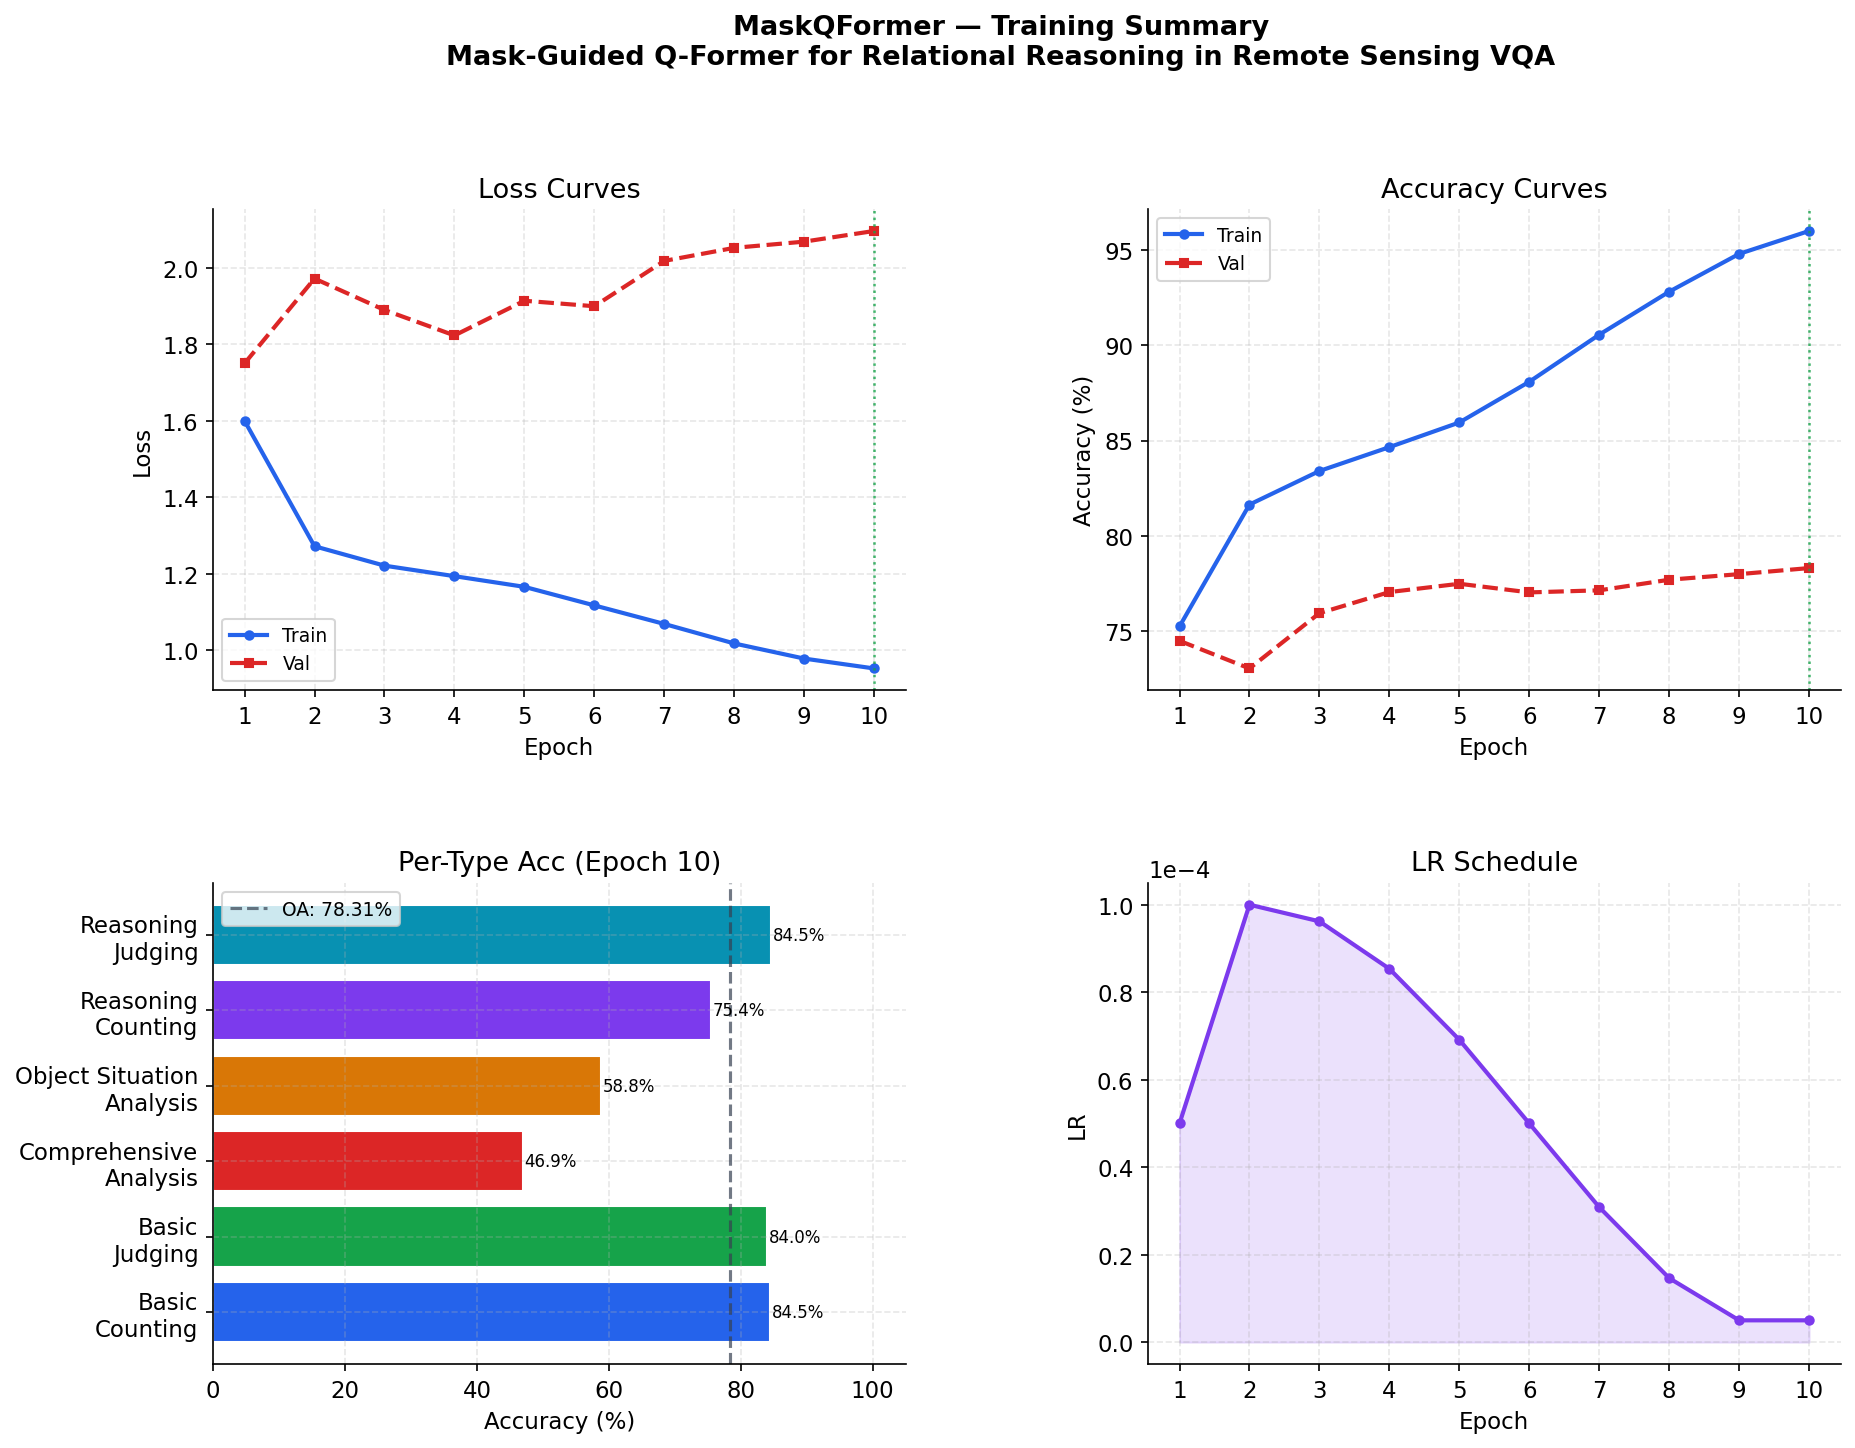

Saved fig7_summary_dashboard.png


In [48]:
# ── Figure 7: Summary Dashboard ──────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Top-left: Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, train_loss, 'o-', color='#2563EB', lw=2, markersize=4, label='Train')
ax1.plot(epochs, val_loss,   's--', color='#DC2626', lw=2, markersize=4, label='Val')
ax1.axvline(best_epoch, color='#16A34A', lw=1.2, linestyle=':', alpha=0.8)
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=9)
ax1.set_xticks(epochs)

# Top-right: Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, [a*100 for a in train_acc], 'o-', color='#2563EB', lw=2, markersize=4, label='Train')
ax2.plot(epochs, [a*100 for a in val_acc],   's--', color='#DC2626', lw=2, markersize=4, label='Val')
ax2.axvline(best_epoch, color='#16A34A', lw=1.2, linestyle=':', alpha=0.8)
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend(fontsize=9)
ax2.set_xticks(epochs)

# Bottom-left: Per-type bar
ax3 = fig.add_subplot(gs[1, 0])
vals = [best_type[t] * 100 for t in TYPE_NAMES]
ax3.barh(short_names, vals, color=colors, edgecolor='white')
ax3.axvline(best_acc * 100, color='#374151', lw=1.5,
            linestyle='--', alpha=0.7, label=f'OA: {best_acc*100:.2f}%')
for i, v in enumerate(vals):
    ax3.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)
ax3.set_title(f'Per-Type Acc (Epoch {best_epoch})')
ax3.set_xlabel('Accuracy (%)')
ax3.set_xlim(0, 105)
ax3.legend(fontsize=9)

# Bottom-right: LR
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(epochs, lr_vals, 'o-', color='#7C3AED', lw=2, markersize=4)
ax4.fill_between(epochs, lr_vals, alpha=0.15, color='#7C3AED')
ax4.set_title('LR Schedule')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('LR')
ax4.set_xticks(epochs)
ax4.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

fig.suptitle(
    'MaskQFormer — Training Summary\n'
    'Mask-Guided Q-Former for Relational Reasoning in Remote Sensing VQA',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(FIG_DIR / 'fig7_summary_dashboard.png', bbox_inches='tight')
plt.show()
print("Saved fig7_summary_dashboard.png")

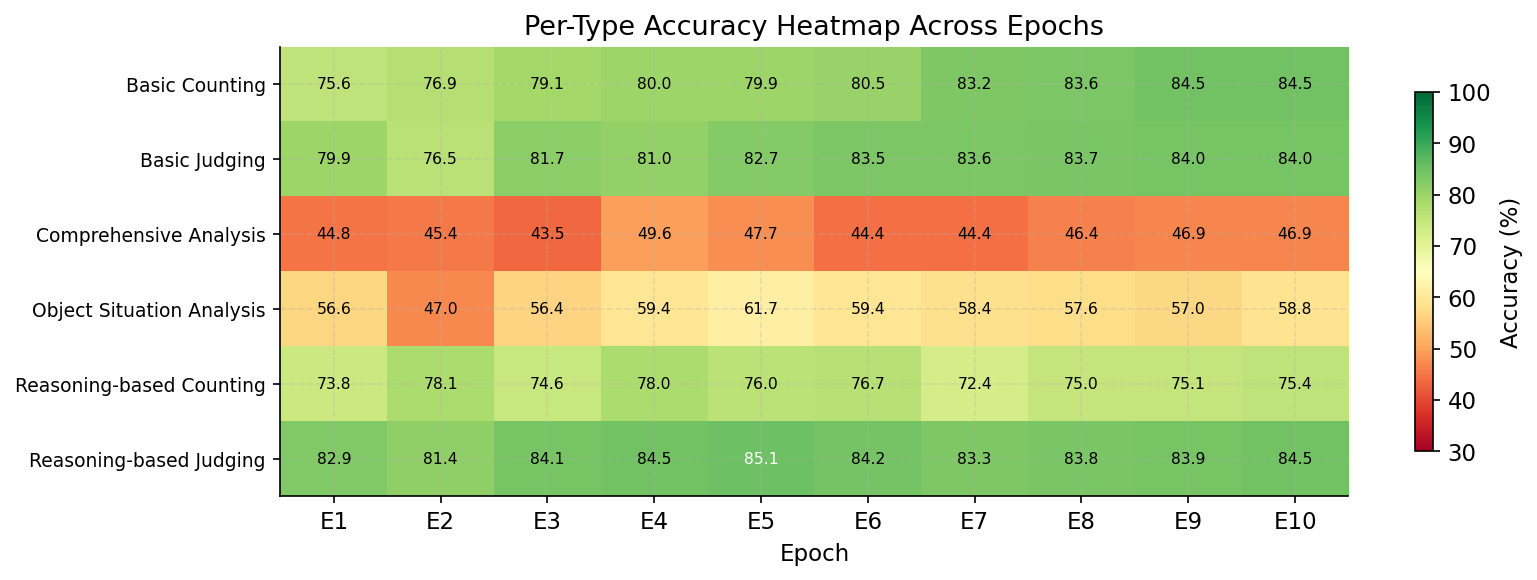

Saved fig8_per_type_heatmap.png


In [49]:
# ── Figure 8: Per-Type Heatmap Across Epochs ────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))

matrix = np.array([
    [per_type_epochs[t][i] * 100 for i in range(len(epochs))]
    for t in TYPE_NAMES
])

im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn',
               vmin=30, vmax=100)

ax.set_xticks(range(len(epochs)))
ax.set_xticklabels([f'E{e}' for e in epochs])
ax.set_yticks(range(len(TYPE_NAMES)))
ax.set_yticklabels(TYPE_NAMES, fontsize=9)

for i in range(len(TYPE_NAMES)):
    for j in range(len(epochs)):
        val = matrix[i, j]
        ax.text(j, i, f'{val:.1f}',
                ha='center', va='center',
                fontsize=7.5,
                color='black' if 40 < val < 85 else 'white')

plt.colorbar(im, ax=ax, label='Accuracy (%)', shrink=0.8)
ax.set_title('Per-Type Accuracy Heatmap Across Epochs')
ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_per_type_heatmap.png')
plt.show()
print("Saved fig8_per_type_heatmap.png")

In [50]:
# ── Print Results Table (paper-ready) ───────────────────────────────────
print("=" * 60)
print("  MASKQFORMER — RESULTS SUMMARY")
print("  Mask-Guided Q-Former for RS-VQA")
print("=" * 60)
print(f"  Best Epoch:     {best_epoch}")
print(f"  Overall OA:     {best_acc*100:.2f}%")
print()
print("  Per-Type Accuracy:")
print("  " + "-" * 45)
for t in TYPE_NAMES:
    print(f"  {t:<30} {best_type[t]*100:.2f}%")
print("  " + "-" * 45)
print(f"  {'Overall Accuracy':<30} {best_acc*100:.2f}%")
print("=" * 60)
print(f"\n  Figures saved to: {FIG_DIR}")
print("  Files:")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"    {f.name}")

  MASKQFORMER — RESULTS SUMMARY
  Mask-Guided Q-Former for RS-VQA
  Best Epoch:     10
  Overall OA:     78.31%

  Per-Type Accuracy:
  ---------------------------------------------
  Basic Counting                 84.48%
  Basic Judging                  83.95%
  Comprehensive Analysis         46.91%
  Object Situation Analysis      58.75%
  Reasoning-based Counting       75.43%
  Reasoning-based Judging        84.52%
  ---------------------------------------------
  Overall Accuracy               78.31%

  Figures saved to: d:\amir lab\RS-Vamba-main\fusion\outputs\figures
  Files:
    fig1_loss_curves.png
    fig2_accuracy_curves.png
    fig3_per_type_accuracy.png
    fig4_per_type_across_epochs.png
    fig5_lr_schedule.png
    fig6_generalization_gap.png
    fig7_summary_dashboard.png
    fig8_per_type_heatmap.png
